In [132]:
import numpy as np
import matplotlib.pyplot as plt
from objprint import op
from PIL import Image
from tqdm import tqdm
import cv2
import sys
import os
from matplotlib.colors import ListedColormap

sys.path.append("/home/arno/Projects/Pint3D/print_ngp/util")

import printer.printerICM as icm


In [139]:
volume = np.load("ColorWheel/volumeWheel/colorWheelVolume.npz")["volume"]
# volume = np.load("ColorWheel/volumeWheel/colorWheelVolumeWhiteInTheMiddle.npz")["volume"]
# volume = np.load("/home/arno/Projects/Pint3D/print_data/Gau/lego_crop_newtest/array/allData.npy")
print("Volume Shape: ",volume.shape)
print("RGB max",volume[0][:,:,:3].max())
print("Alpha max",volume[0][:,:,3].max())

Volume Shape:  (118, 236, 714, 4)
RGB max 1.0
Alpha max 1.0


In [26]:
# 获取当前 alpha 通道的最大值
alpha_max = volume[:, :, :, 3].max()

# 将 alpha 通道除以最大值进行归一化
volume[:, :, :, 3] = volume[:, :, :, 3] / alpha_max

# 验证新的 alpha 通道最大值


In [3]:
# 获取当前 alpha 通道
alpha_channel = volume[:, :, :, 3]

# 使用 clip 将 alpha 通道值限制在 [0, 1] 范围内
volume[:, :, :, 3] = np.clip(alpha_channel, 0, 1)

In [137]:
print(f" Alpha 最大值： {volume[:, :, :, 3].max()}")


 Alpha 最大值： 3486.736083984375


In [52]:
#  将alpha乘在rgb上 预乘 alpha（premultiplied alpha）
alpha_channel = volume[:, :, :, 3].copy()
alpha_channel = np.clip(alpha_channel, 0, 1)


for i in range(3):  # 对应 RGB 三个通道
    volume[:, :, :, i] = volume[:, :, :, i] * alpha_channel
    
print("已将 alpha 通道乘到 RGB 通道上")

已将 alpha 通道乘到 RGB 通道上


标识码 50单位长度



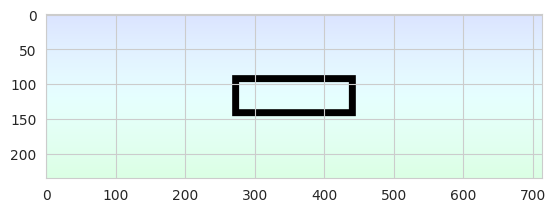

In [140]:
# 和之前一样的处理方式，但是不用超分了：顶面加一个空心方框
image = volume[0]
# 获取图像尺寸
height, width, _ = image.shape

# 定义方框的尺寸（可以根据需要调整）
box_height = height // 4  # 高度为图像高度的1/4
box_width = width // 4    # 宽度为图像宽度的1/4

# 计算方框的左上角坐标，使其居中
top = (height - box_height) // 2
left = (width - box_width) // 2

# 计算方框的右下角坐标
bottom = top + box_height
right = left + box_width

# 定义线条宽度
line_width = 10
# 创建黑色线条 (0,0,0,100)
black_color = np.array([0, 0, 0, 1], dtype=image.dtype)

# 绘制上边框
image[top:top+line_width, left:right] = black_color

# 绘制下边框
image[bottom-line_width:bottom, left:right] = black_color

# 绘制左边框
image[top:bottom, left:left+line_width] = black_color

# 绘制右边框
image[top:bottom, right-line_width:right] = black_color
plt.imshow(image)
plt.show()



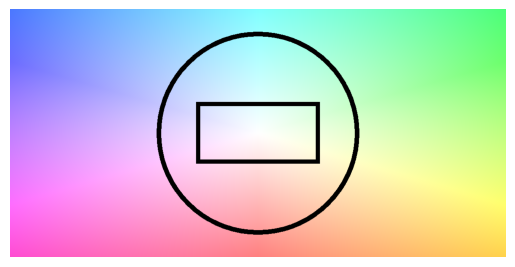

In [5]:
# 表面10层没有任何白色：顶面加一个空心圆圈

# 假设volume[0]是你的图像
image = volume[0]

# 获取图像尺寸
height, width, _ = image.shape

# 定义圆的参数
center = (width // 2, height // 2)
radius = min(height, width) // 5 *2
line_width = 10  # 线条宽度

# 定义黑色线条 (0,0,0,255) - OpenCV使用BGR格式
black_color = (0, 0, 0, 255)

# 绘制圆圈
# 注意：OpenCV的circle函数在RGBA图像上可能不能正常工作
# 所以我们需要分别处理每个通道
temp_image = image.copy()

# 创建一个单通道掩码
mask = np.zeros((height, width), dtype=np.uint8)
cv2.circle(mask, center, radius, 255, line_width)

# 使用掩码将圆圈区域设置为黑色
image[mask > 0] = np.array([0, 0, 0, 1], dtype=image.dtype)

# 显示结果
plt.imshow(image)
plt.axis('off')  # 隐藏坐标轴
plt.show()


首先对volume进行icc颜色变换

In [90]:
import numpy as np
from PIL import Image
import PIL.ImageCms as ImageCms
import pandas as pd


def white_weight_func(cmyk_sum):
    # return np.exp(-cmyk_sum * 5)  # 指数衰减函数
    white_threshold = 0.8*255  # 可调整的阈值
    white_weight = np.maximum(0, white_threshold - cmyk_sum)
    return white_weight


def get_gray_to_cmyk_mapping(srgb_profile_path, cmyk_profile_path):
    """获取灰度值(0-255)到CMYK的映射表"""
    # 创建一个包含所有灰度值的图像
    grayscale_strip = np.arange(256, dtype=np.uint8).reshape(1, 256)
    gray_img = Image.fromarray(grayscale_strip, mode='L')
    
    # 转换为RGB (因为ICC转换需要RGB输入)
    rgb_img = gray_img.convert('RGB')
    
    cmyk_img = icm.convert_color_profile(
    rgb_img,
    modes=[1],
    srgb_profile_path="/home/arno/Projects/Pint3D/print_ngp/util/printer/icc/AdobeRGB1998.icc",
    cmyk_profile_path="/home/arno/Projects/Pint3D/print_ngp/util/printer/icc/Stratasys_J8_7xx_VeroUltraWhite_HT3_VividCMYK.icm",
    output_mode="CMYK",
    save_files=False
    )[0]
    
    # 提取CMYK值
    cmyk_array = np.array(cmyk_img)
    cmyk_values = cmyk_array[0]  # 提取第一行
    cmyk_sum=np.sum(cmyk_values,axis=1)
    
    for i  in range(len(cmyk_sum)):
        cmyk_sum[i]=white_weight_func(cmyk_sum[i])
    
    # w=white_weight_func(np.sum(cmyk_values))
    
    # 创建映射表
    mapping = {}
    for i in range(256):
        mapping[i] = tuple([*cmyk_values[i],cmyk_sum[i]])
    
    # 创建DataFrame并保存为CSV
    df = pd.DataFrame({
        'Gray': range(256),
        'Cyan': [mapping[i][0] for i in range(256)],
        'Magenta': [mapping[i][1] for i in range(256)],
        'Yellow': [mapping[i][2] for i in range(256)],
        'Black': [mapping[i][3] for i in range(256)],
        'White': [mapping[i][4] for i in range(256)]
    })
    
    df.to_csv('gray_to_cmyk_mapping.csv', index=False)
    print("映射表已保存为 gray_to_cmyk_mapping.csv")
    
    return mapping

# 使用示例
srgb_profile_path="/home/arno/Projects/Pint3D/print_ngp/util/printer/icc/AdobeRGB1998.icc",
cmyk_profile_path="/home/arno/Projects/Pint3D/print_ngp/util/printer/icc/Stratasys_J8_7xx_VeroUltraWhite_HT3_VividCMYK.icm",

mapping = get_gray_to_cmyk_mapping(srgb_profile_path, cmyk_profile_path)

# 打印部分结果
print("部分映射结果:")
for i in [0, 50, 100, 150, 200, 255]:
    print(f"灰度值 {i} -> CMYK: {mapping[i]}")


映射表已保存为 gray_to_cmyk_mapping.csv
部分映射结果:
灰度值 0 -> CMYK: (np.uint8(53), np.uint8(34), np.uint8(0), np.uint8(255), np.uint64(0))
灰度值 50 -> CMYK: (np.uint8(187), np.uint8(153), np.uint8(107), np.uint8(187), np.uint64(0))
灰度值 100 -> CMYK: (np.uint8(154), np.uint8(163), np.uint8(123), np.uint8(20), np.uint64(0))
灰度值 150 -> CMYK: (np.uint8(90), np.uint8(117), np.uint8(101), np.uint8(0), np.uint64(0))
灰度值 200 -> CMYK: (np.uint8(43), np.uint8(59), np.uint8(57), np.uint8(0), np.uint64(45))
灰度值 255 -> CMYK: (np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint64(204))


In [113]:
volume_icc=np.zeros((volume.shape[0],volume.shape[1],volume.shape[2],4))
for i in tqdm(range(volume.shape[0]),desc="icc correcting..."):
    slice=volume[i]
    rgb_slice = slice.copy()
    # rgb_slice=rgb_slice[:,:,:3]
    rgb_slice[:, :, 0] = slice[:, :, 2]  # R = B
    rgb_slice[:, :, 2] = slice[:, :, 0]  # B = R
    # G通道保持不变
    slice = (rgb_slice * 255).astype(np.uint8)
    img = Image.fromarray(slice)
    output_files = icm.convert_color_profile(
        img,
        modes=[1],
        srgb_profile_path="/home/arno/Projects/Pint3D/print_ngp/util/printer/icc/AdobeRGB1998.icc",
        cmyk_profile_path="/home/arno/Projects/Pint3D/print_ngp/util/printer/icc/Stratasys_J8_7xx_VeroUltraWhite_HT3_VividCMYK.icm",
        output_mode="CMYK",
        save_files=False
    )
    volume_icc[i]=np.array(output_files[0])

icc correcting...: 100%|██████████| 714/714 [00:15<00:00, 45.56it/s]


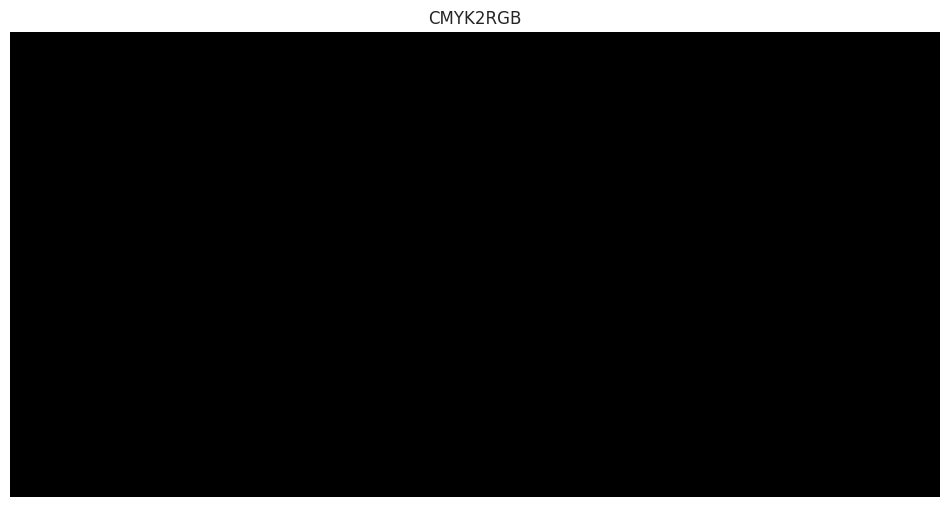

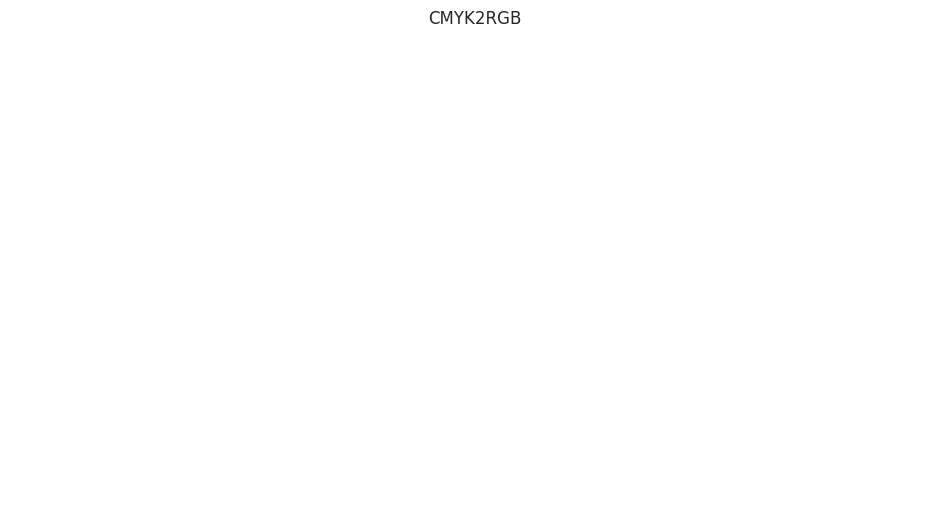

In [114]:
def show_cmyk_slice(cmyk_slice):
    # cmyk_slice  # 形状为(..., 4)
    # 确保数据类型正确
    if cmyk_slice.dtype != np.uint8:
        if cmyk_slice.max() <= 255.0:
            cmyk_slice = cmyk_slice.astype(np.uint8)
        else:
            cmyk_slice = (cmyk_slice / cmyk_slice.max() * 255).astype(np.uint8)

    # 创建CMYK模式的PIL图像
    cmyk_img = Image.fromarray(cmyk_slice, mode='CMYK')

    # 方法1：转换为RGB后显示
    rgb_img = cmyk_img.convert('RGB')
    plt.figure(figsize=(12, 8))
    plt.imshow(rgb_img)
    plt.title("CMYK2RGB")
    plt.axis('off')
    plt.show()
    
show_cmyk_slice(volume_icc[0])
show_cmyk_slice(volume_icc[357])
# show_cmyk_slice(volume_icc[500])
# show_cmyk_slice(volume_icc[10])
    

In [42]:
from printer.printerHelper import getVoxelSize

x_length,y_length,z_length=getVoxelSize()

boundary=0.4

x_boundary=int(boundary/x_length)
y_boundary=int(boundary/y_length)
z_boundary=int(boundary/z_length)

print("边界范围",x_boundary,y_boundary,z_boundary)

for i in tqdm(range(z_boundary,volume_icc_halftone.shape[0]-z_boundary), desc="cutting boundary..."):
    slice=volume_icc_halftone[i]
    slice[x_boundary:slice.shape[0]-x_boundary,y_boundary:slice.shape[1]-y_boundary]=4
    volume_icc_halftone[i]=slice

    


边界范围 4 9 28


cutting boundary...: 100%|██████████| 301/301 [00:00<00:00, 2518.22it/s]


In [76]:
density_slice = volume[0][...,3]
alpha_slice = 1 - np.exp(-1 * (density_slice) * 0.014)
alpha_slice

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(214, 767), dtype=float32)

In [121]:

volume_icc_halftone = np.zeros((volume_icc.shape[0], volume_icc.shape[1], volume_icc.shape[2]))

def white_weight_func(cmyk_sum):
    # return np.exp(-cmyk_sum * 5)  # 指数衰减函数
    white_threshold = 0.8*255  # 可调整的阈值
    white_weight = np.maximum(0, white_threshold - cmyk_sum)
    return white_weight

for i in tqdm(range(volume_icc.shape[0]), desc="halftone sampling..."):
    cmyk_slice = volume_icc[i]
    
    density_slice = volume[i][...,3]
    # alpha_slice = 1 - np.exp(-1 * (density_slice) * 0.014)
    alpha_slice=density_slice
    alphaMask= np.random.random((height, width))
    
    # 创建采样结果数组
    height, width, channels = cmyk_slice.shape
    sampled_image = np.zeros((height, width), dtype=np.uint8)
    # 确保所有值都是非负的
    cmyk_values = np.maximum(cmyk_slice, 0)
    # 计算CMYK的总和
    cmyk_sum = np.sum(cmyk_values, axis=-1)


    # 定义白色通道的权重
    white_weight = white_weight_func(cmyk_sum)
    
    # 创建包含白色通道的5通道数组 [C, M, Y, K, White]
    cmyk_w_values = np.zeros((height, width, 5))
    cmyk_w_values[:, :, :4] = cmyk_values  # 前4个通道是CMYK
    cmyk_w_values[:, :, 4] = white_weight  # 第5个通道是白色
    
    # 计算总和（包括白色通道）
    totals = np.sum(cmyk_w_values, axis=-1)
    
    # 生成随机数数组 (0到1之间的随机数乘以总和)
    r = np.random.random((height, width)) * totals
    
    # 计算累积和
    cumulative = np.cumsum(cmyk_w_values, axis=-1)
    
    # 初始化采样结果为全0
    sampled_image = np.zeros((height, width), dtype=np.uint8)
    for k in range(1, 6):  # 从通道1开始，因为通道0是默认值
        sampled_image = np.where(r >= cumulative[:, :, k-1], k, sampled_image)
    
    # 处理总和为0的情况
    zero_totals = (totals == 0)
    if np.any(zero_totals):
        print(f"Layer {i}: ZERO!!")
    
    sampled_image[alphaMask>alpha_slice]=5
    # np.where(alphaMask>alpha_slice,5,sampled_image)

    volume_icc_halftone[i] = sampled_image


halftone sampling...:   0%|          | 0/714 [00:00<?, ?it/s]

halftone sampling...: 100%|██████████| 714/714 [00:01<00:00, 499.95it/s]


In [96]:
# 可视化采样结果
def previewHalftone(sampled_image, cmyk_slice): 
    # 更新颜色映射以包含白色
    cmap = plt.cm.colors.ListedColormap(['cyan', 'magenta', 'yellow', 'black', 'white', "grey"])
    bounds = [0, 1, 2, 3, 4, 5, 6]
    norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)

    plt.figure(figsize=(12, 8))
    plt.imshow(sampled_image, cmap=cmap, norm=norm)
    plt.colorbar(ticks=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], label='')
    plt.clim(-0.5, 5.5)
    plt.title('CMYKW Halftone')
    plt.axis('off')
    plt.show()

    # 显示原始CMYK值和计算的白色通道值的分布
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    channel_names = ['C (River)', 'M (Flower)', 'Y (Yellow)', 'K (Black)', "White"]

    # 原始CMYK切片
    cmyk_values = np.maximum(cmyk_slice, 0)

    # 计算CMYK的总和
    cmyk_sum = np.sum(cmyk_values, axis=-1)

    # 显示CMYK通道
    for i in range(4):
        im = axes[i].imshow(cmyk_values[:, :, i], cmap='viridis')
        axes[i].set_title(f'{channel_names[i]}')
        axes[i].axis('off')
        plt.colorbar(im, ax=axes[i])

    # 显示白色通道
    white_weight = white_weight_func(cmyk_sum)
    im = axes[4].imshow(white_weight, cmap='viridis')
    axes[4].set_title(f'{channel_names[4]}')
    axes[4].axis('off')
    plt.colorbar(im, ax=axes[4])

    plt.tight_layout()
    plt.show()


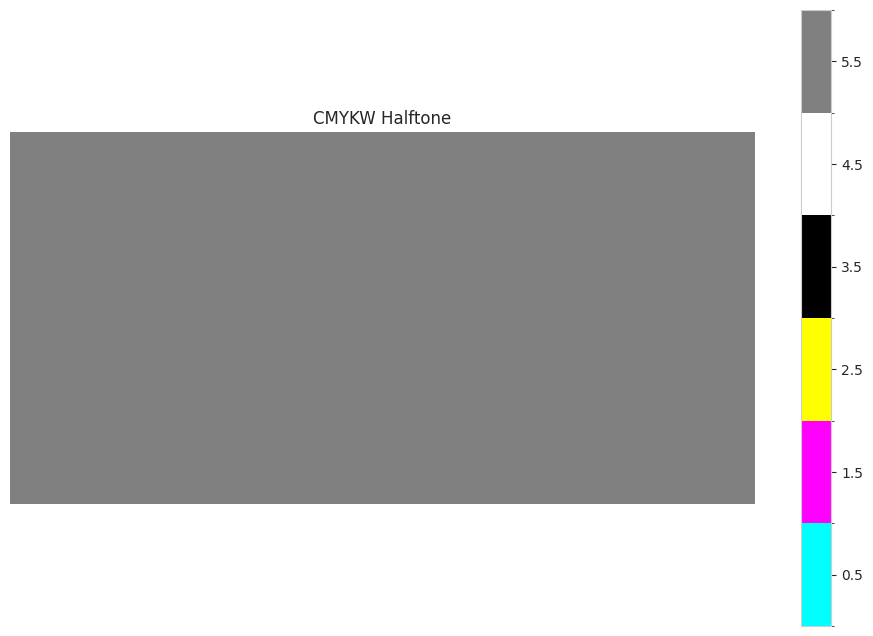

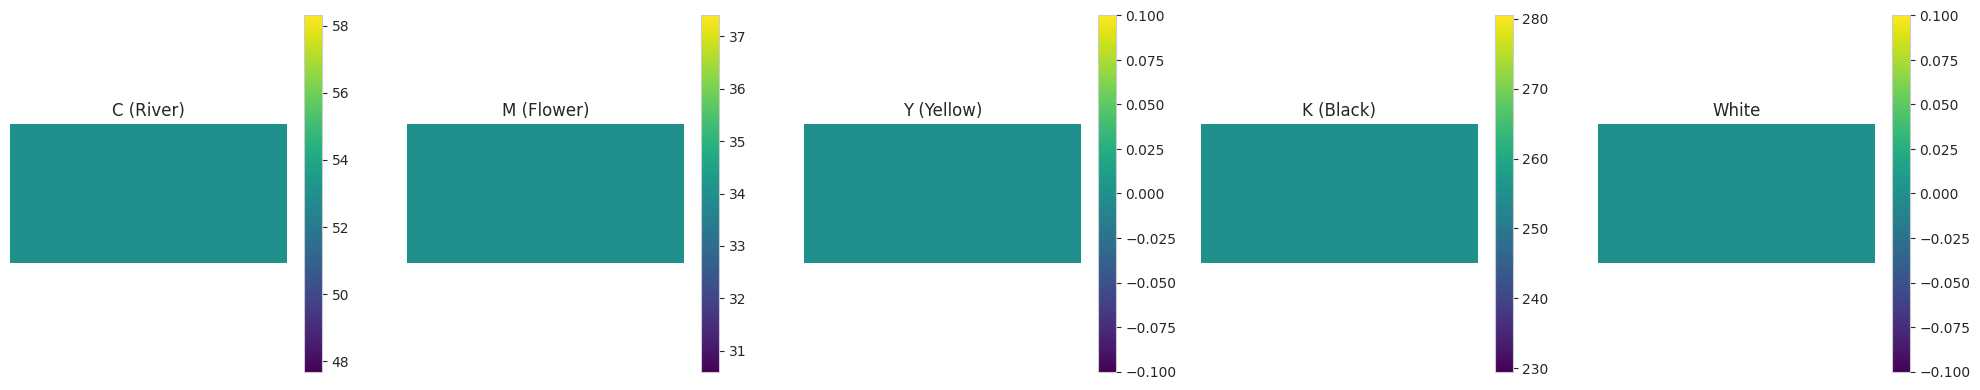

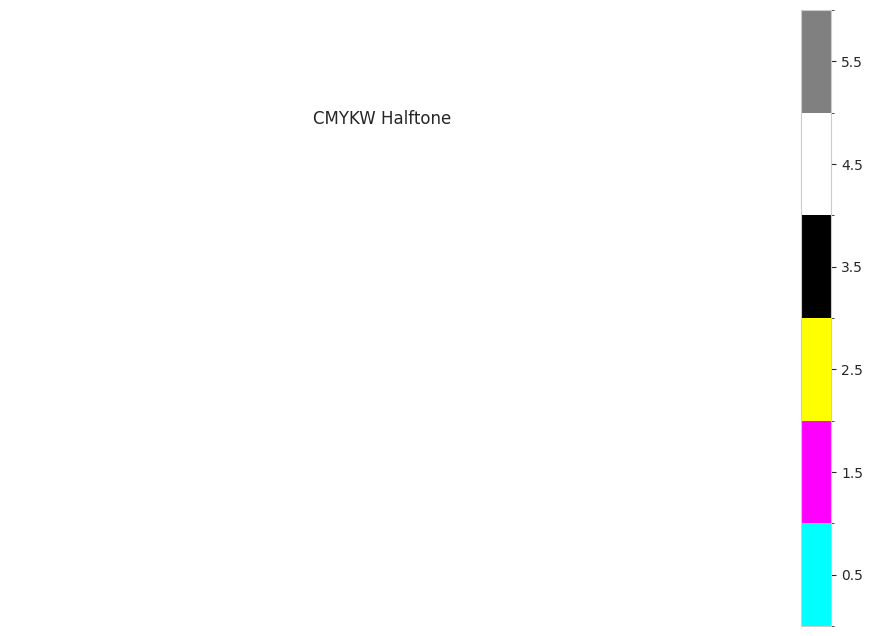

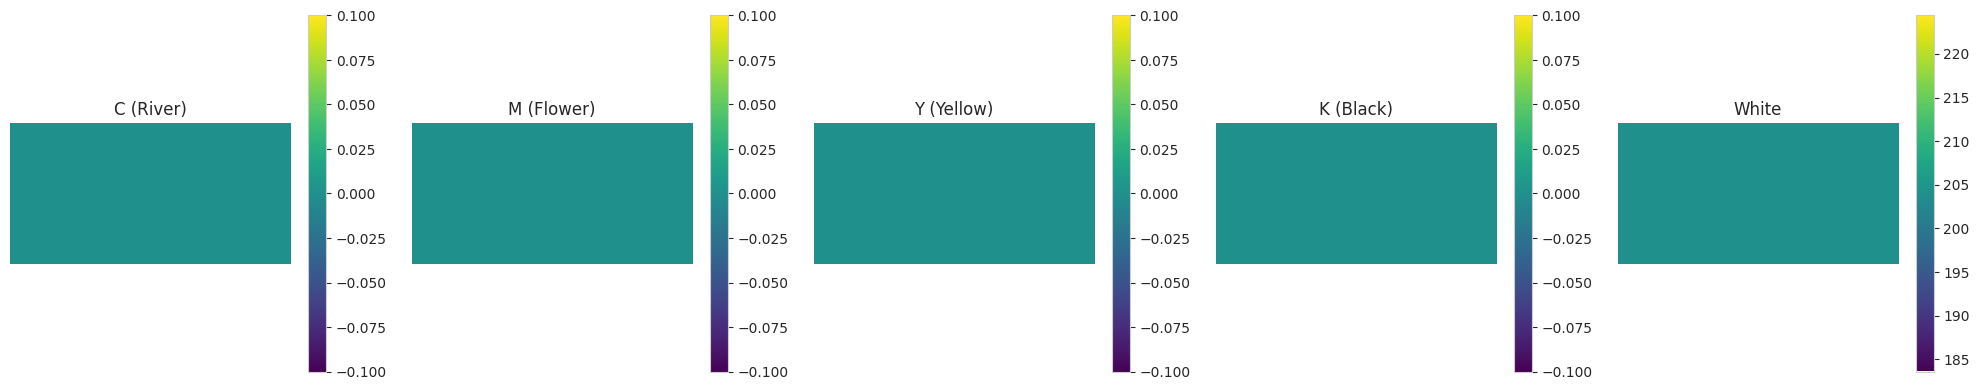

In [122]:
previewHalftone(volume_icc_halftone[0], volume_icc[0])
# previewHalftone(volume_icc_halftone[500], volume_icc[500])
previewHalftone(volume_icc_halftone[357], volume_icc[357])


In [100]:
from printer.printerHelper import getVoxelSize

In [105]:
x_length, y_length,_=getVoxelSize()

In [123]:
# 切圆形
x_center=getVoxelSize()[1]//2

for i in tqdm(range(volume_icc_halftone.shape[0]), desc="cutting circle..."):
    slice = volume_icc_halftone[i].copy()
    x_center = slice.shape[1]//2
    y_center = slice.shape[0]//2
    # 计算坐标到中心的dx,dy
    y_coords, x_coords = np.ogrid[:slice.shape[0], :slice.shape[1]]
    dist_from_center = np.sqrt(((x_coords - x_center)*y_length)**2 + ((y_coords - y_center)*x_length)**2)
    # 设置距离中心50mm以外的像素为5
    slice[dist_from_center > 25] = 5
    # previewHalftone(slice,volume_icc[-1])
    # break
    volume_icc_halftone[i] = slice

cutting circle...: 100%|██████████| 714/714 [00:00<00:00, 9956.95it/s]


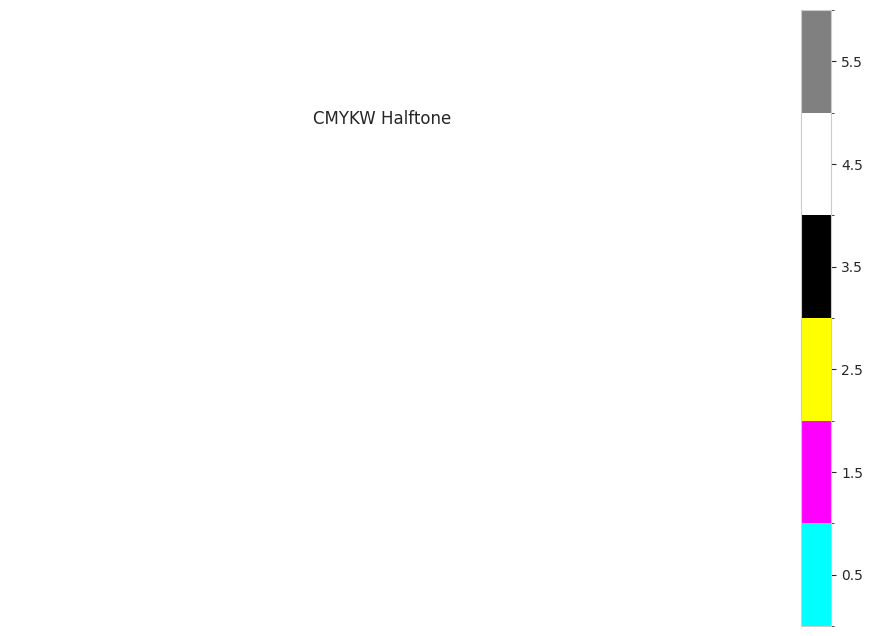

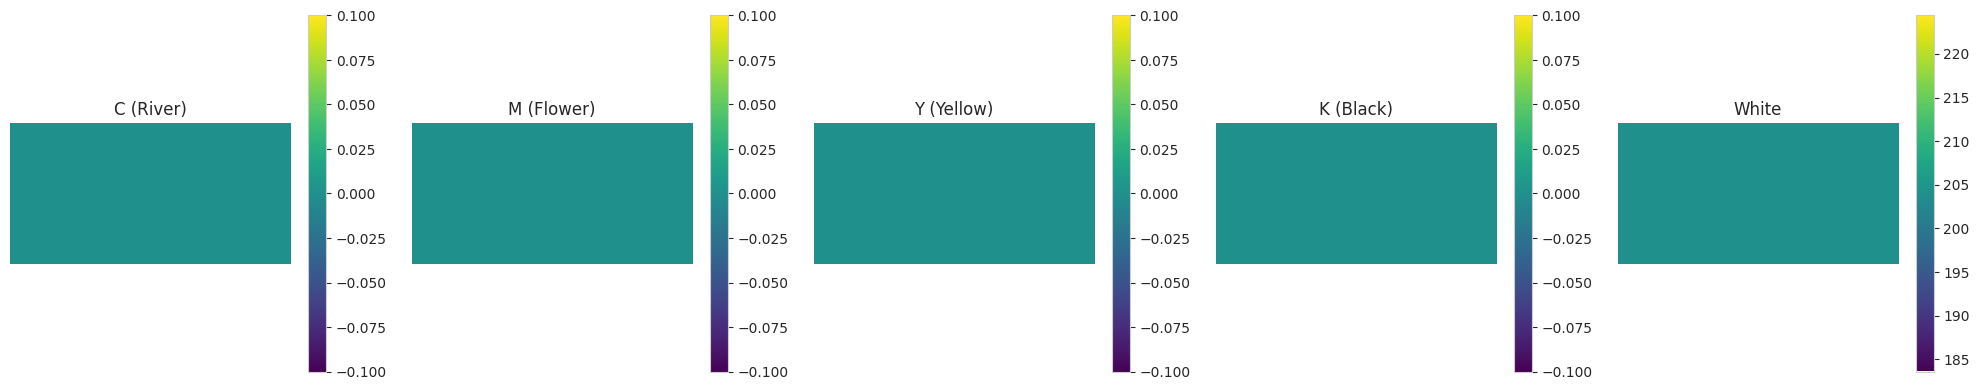

In [125]:
previewHalftone(volume_icc_halftone[357], volume_icc[357])


In [129]:
# SaveFolder = "ColorWheel/volumeWheel/colorSampleHalftone"
# SaveFolder = "ColorWheel/volumeWheel/colorSampleHalftone3Dv1"
# SaveFolder = "ColorWheel/volumeWheel/colorSampleHalftone3Dv3"


# SaveFolder = "ColorWheel/volumeWheel/v4-WhiteInside"
# SaveFolder = "ColorWheel/volumeWheel/v4-Black"
SaveFolder = "ColorWheel/volumeWheel/whiteSliceBlock"
# 确保目标目录存在
os.makedirs(SaveFolder, exist_ok=True)
# 删除其中所有文件
for file in os.listdir(SaveFolder):
    os.remove(f"{SaveFolder}/{file}")

# 创建自定义颜色映射: 0=C, 1=M, 2=Y, 3=K, 4=W, 5=透明
# 使用CMYK对应的RGB值
colors = [
    [0, 1, 1],    # C - 青色 (RGB: 0, 255, 255)
    [1, 0, 1],    # M - 品红 (RGB: 255, 0, 255)  
    [1, 1, 0],    # Y - 黄色 (RGB: 255, 255, 0)
    [0, 0, 0],    # K - 黑色 (RGB: 0, 0, 0)
    [1, 1, 1],    # W - 白色 (RGB: 255, 255, 255)
    [0.0, 0.0, 0.0],    # 边缘 - 灰色 (RGB: 255, 255, 255)
    # [0.7, 0.7, 0.7],    # 边缘 - 灰色 (RGB: 255, 255, 255)
]

# 创建自定义颜色映射
cmap = ListedColormap(colors)  # 不包括透明色，我们会单独处理透明度

for i in tqdm(range(volume_icc_halftone.shape[0]), desc="saving png slices..."):
    slice_data = volume_icc_halftone[i].copy()
    
    # 创建RGBA图像
    rgba_image = np.ones((slice_data.shape[0], slice_data.shape[1], 4))
    
    # 设置RGB颜色
    for val in range(len(colors)):  # 处理0-4的值
        mask = (slice_data == val)
        rgba_image[mask, 0] = colors[val][0]
        rgba_image[mask, 1] = colors[val][1]
        rgba_image[mask, 2] = colors[val][2]
    
    # 设置透明度 - 只有值为5的像素是透明的
    rgba_image[slice_data == 5, 3] = 0  # 设置透明度为0
    
    # 保存图像
    plt.imsave(f"{SaveFolder}/{i:04d}.png", rgba_image)

saving png slices...: 100%|██████████| 714/714 [00:01<00:00, 657.95it/s]


In [127]:
# 压缩文件夹到zip
import os


# cmd="cd /home/arno/Projects/Pint3D/print_ngp/Mesh2Volume/ColorWheel && zip -r 20250401_volumeWheel.zip volumeWheel"
cmd="cd /home/arno/Projects/Pint3D/print_ngp/Mesh2Volume/ColorWheel && zip -r 20250401_volumeWheel.zip volumeWheel -x '*.npy' -x '*.npz'"

os.system(cmd)

  adding: volumeWheel/ (stored 0%)
  adding: volumeWheel/preview-view1.mp4 (deflated 47%)
  adding: volumeWheel/whiteSliceBlock/ (stored 0%)
  adding: volumeWheel/whiteSliceBlock/0570.png (deflated 61%)
  adding: volumeWheel/whiteSliceBlock/0707.png (deflated 61%)
  adding: volumeWheel/whiteSliceBlock/0435.png (deflated 61%)
  adding: volumeWheel/whiteSliceBlock/0027.png (deflated 61%)
  adding: volumeWheel/whiteSliceBlock/0001.png (deflated 61%)
  adding: volumeWheel/whiteSliceBlock/0527.png (deflated 61%)
  adding: volumeWheel/whiteSliceBlock/0390.png (deflated 61%)
  adding: volumeWheel/whiteSliceBlock/0279.png (deflated 61%)
  adding: volumeWheel/whiteSliceBlock/0170.png (deflated 61%)
  adding: volumeWheel/whiteSliceBlock/0099.png (deflated 61%)
  adding: volumeWheel/whiteSliceBlock/0345.png (deflated 61%)
  adding: volumeWheel/whiteSliceBlock/0102.png (deflated 61%)
  adding: volumeWheel/whiteSliceBlock/0041.png (deflated 61%)
  adding: volumeWheel/whiteSliceBlock/0232.png (defla

0